In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind,f_oneway,chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report
import warnings
import joblib

In [ ]:
warnings.filterwarnings('ignore')

#styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

print("✅All Libraries imported successfully!")


✅All Libraries imported successfully!


In [ ]:
df=pd.read_csv(r'D:\ML Project\Student Performence\student_performance.csv')

print(f"Data shape: {df.shape}")
df.head(50)

Data shape: (14003, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2
5,19,64,1,1,0,1,0,28,1,19,0,67,99,1,1,0
6,19,64,0,1,0,1,0,19,2,8,1,59,40,0,1,3
7,19,64,0,1,0,1,0,23,3,16,0,90,66,0,1,2
8,19,64,0,1,0,1,0,28,1,19,0,67,99,1,1,0
9,19,64,1,1,1,1,0,19,2,8,1,59,40,0,1,3


In [ ]:
df.columns


Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')

In [ ]:
df.shape

(14003, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [ ]:
df.describe()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


In [ ]:
df.isnull().sum()

StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

In [ ]:
df.isnull().sum()/len(df)*100

StudyHours              0.0
Attendance              0.0
Resources               0.0
Extracurricular         0.0
Motivation              0.0
Internet                0.0
Gender                  0.0
Age                     0.0
LearningStyle           0.0
OnlineCourses           0.0
Discussions             0.0
AssignmentCompletion    0.0
ExamScore               0.0
EduTech                 0.0
StressLevel             0.0
FinalGrade              0.0
dtype: float64

In [ ]:
def descriptive_stats(data):
    """Comprehensive Descriptive Statistics"""
    if isinstance(data,pd.Series):
        data=data.values
    stats_dict={
        'count':len(data),
        'mean': np.mean(data),
        'median': np.median(data),
        'std': np.std(data,ddof=1),
        'min': np.min(data),
        'max': np.max(data),
        'q1': np.percentile(data,25),
        'q3': np.percentile(data,75),
        'iqr': np.percentile(data, 75)-np.percentile(data,25),
        'skewness': stats.skew(data),
        'kurtosis': stats.kurtosis(data)
    }
    return pd.Series(stats_dict)

#example usage
print("Descriptive Statistics for ExamScore: ")
print(descriptive_stats(df['ExamScore']))

#quick pandas summary
df.describe()

Descriptive Statistics for ExamScore: 
count       14003.000000
mean           70.346926
median         70.000000
std            17.688113
min            40.000000
max           100.000000
q1             55.000000
q3             86.000000
iqr            31.000000
skewness       -0.017949
kurtosis       -1.208528
dtype: float64


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


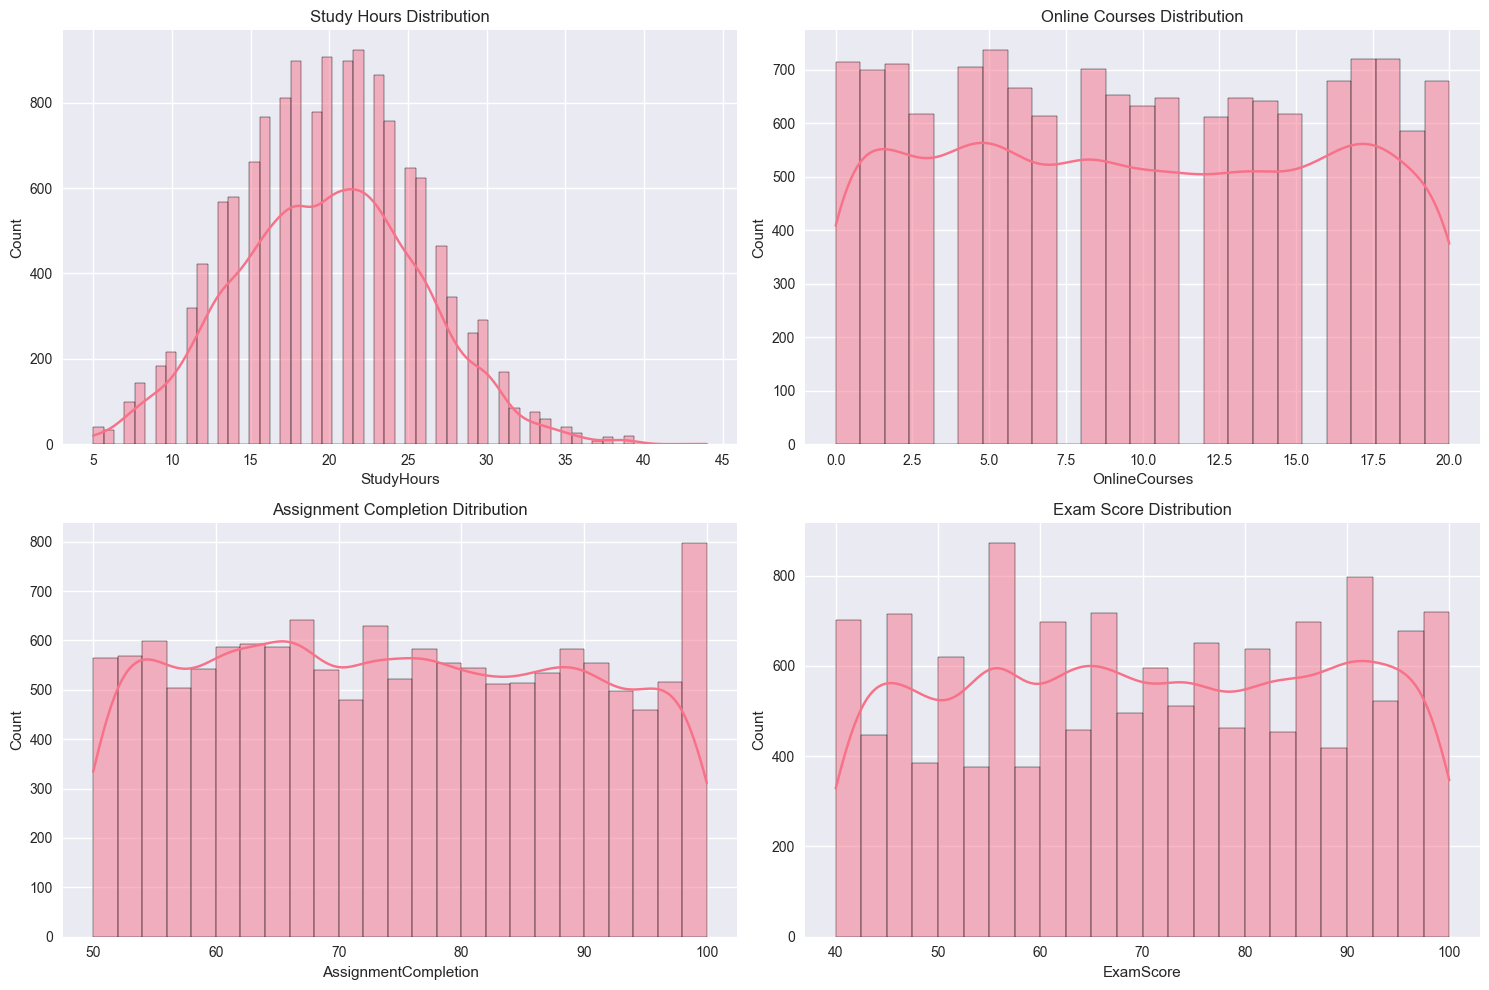

In [ ]:
#Distribution plots
fig,axes=plt.subplots(2,2,figsize=(15,10))
sns.histplot(df['StudyHours'],kde=True,ax=axes[0,0]).set_title('Study Hours Distribution')
sns.histplot(df['OnlineCourses'],kde=True,ax=axes[0,1]).set_title('Online Courses Distribution')
sns.histplot(df['AssignmentCompletion'],kde=True,ax=axes[1,0]).set_title('Assignment Completion Ditribution')
sns.histplot(df['ExamScore'],kde=True,ax=axes[1,1]).set_title('Exam Score Distribution')
plt.tight_layout()
plt.show()

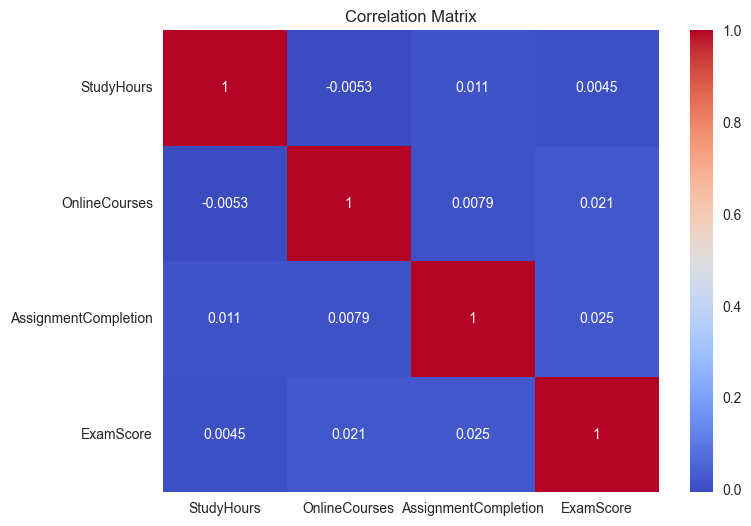

In [ ]:
# correlation,,
plt.figure(figsize=(8,6))
numeric_df = df[['StudyHours', 'OnlineCourses', 'AssignmentCompletion', 'ExamScore']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# print("=== 1. T-Test : AssignmentCompletion by OnlineCourses === ")
# male_age = df[df['OnlineCourses']]['AssignmentCompletion']
# female_age = df[df['OnlineCourses']]['AssignmentCompletion']
# t_stat, p_val = ttest_ind(male_age, female_age)
# print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

In [ ]:
print("\n=== 2. ANOVA: ExamScore by AssignmentCompletion ===")
groups = [group['ExamScore'].values for name, group in df.groupby('AssignmentCompletion')]
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")


=== 2. ANOVA: ExamScore by AssignmentCompletion ===
F-statistic: 5.5235, p-value: 0.0000


In [ ]:
print("\n===3.Chi-Square Test===")
contingency=pd.crosstab(df['StudyHours'],df['OnlineCourses'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square Statistic: {chi2:.4f}, P-value: {p:.4f}")


===3.Chi-Square Test===
Chi-square Statistic: 2317.4513, P-value: 0.0000


In [ ]:
#regression: predict SurvivalMonths 
x = pd.get_dummies(df.drop(['ExamScore'], axis=1), drop_first=True)
y = df['ExamScore']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 
reg_model = LinearRegression()
reg_model.fit(x_train, y_train)
y_pred = reg_model.predict(x_test)

In [ ]:
print("=== Regression Results ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

=== Regression Results ===
R² Score: 0.9402
RMSE: 4.36


In [ ]:
joblib.dump(reg_model, 'Exam_Score_model.pkl')
print(f"Model saved as 'Exam_Score_model.pkl'")

Model saved as 'Exam_Score_model.pkl'


In [ ]:
# Classification: Predict Recurrence
X = pd.get_dummies(df.drop(['StudyHours'], axis=1), drop_first=True)
y = df['StudyHours']
#.map({'Yes': 19, 'No': 24})



In [ ]:
y.isnull().sum()
y.head(25)

0     19
1     19
2     19
3     19
4     19
5     19
6     19
7     19
8     19
9     19
10    19
11    19
12    19
13    19
14    19
15    19
16    19
17    19
18    24
19    24
20    24
21    24
22    24
23    24
24    24
Name: StudyHours, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

print("=== Classification Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

joblib.dump(clf_model, 'recurrence_classifier_model.pkl')
print("✅ Model saved as 'recurrence_classifier_model.pkl'")

=== Classification Results ===
Accuracy: 0.9025
              precision    recall  f1-score   support

           5       1.00      0.22      0.36         9
           6       0.00      0.00      0.00         6
           7       1.00      0.19      0.32        16
           8       0.86      0.57      0.69        21
           9       0.96      0.67      0.79        36
          10       0.94      0.75      0.83        40
          11       0.94      0.69      0.79        67
          12       0.94      0.87      0.90        92
          13       0.84      0.90      0.87       109
          14       0.93      0.93      0.93       119
          15       0.90      0.91      0.91       134
          16       0.91      1.00      0.95       150
          17       0.87      0.99      0.93       161
          18       0.88      0.95      0.91       180
          19       0.94      0.96      0.95       169
          20       0.92      0.99      0.96       188
          21       0.88      0.99